In [85]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pennylane") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pennylane"])

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris,make_circles,make_checkerboard
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")


# Problem 3

### Build a VQC binary classifier to distinguish Iris setosa from Iris versicolor using only the first 2 features.

In [96]:
# load iris
X, y = load_iris(return_X_y=True)
# only the first
X_raw = X[:, :2]
mask = (y == 0) | (y == 1)

# only with values 0 and 1
X_raw = X_raw[mask]
y_raw = y[mask]


#### con dataset de circulos

In [ ]:
# X_raw, y_raw = make_circles(200)



In [97]:
print(X_raw.shape)
print(y_raw.shape)
print(y_raw)

(100, 2)
(100,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [89]:

y_raw = np.where(y_raw == 0, -1, 1)  # labels in {-1, +1}

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)
X_train = np.array(X_train, requires_grad=False)
X_test  = np.array(X_test,  requires_grad=False)
y_train = np.array(y_train, requires_grad=False)
y_test  = np.array(y_test,  requires_grad=False)

#### Grafica del dataset

Training: 150 samples  |  Test: 50 samples


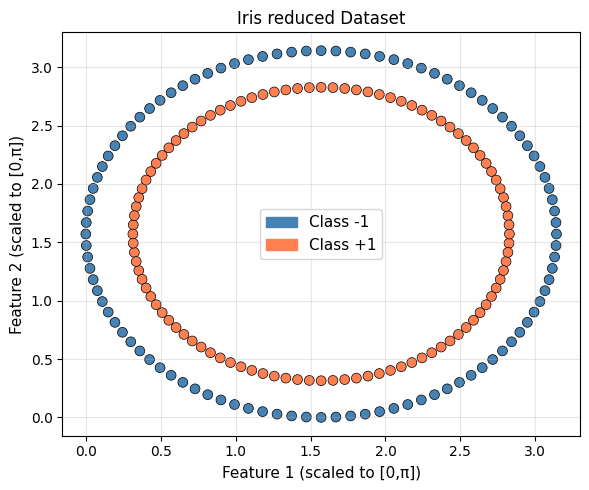

In [90]:
print(f'Training: {len(X_train)} samples  |  Test: {len(X_test)} samples')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue' if y == -1 else 'coral' for y in y_raw]
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, edgecolors='k', linewidths=0.5, s=50)
p1 = mpatches.Patch(color='steelblue', label='Class -1')
p2 = mpatches.Patch(color='coral', label='Class +1')
ax.legend(handles=[p1, p2], fontsize=11)
ax.set_xlabel('Feature 1 (scaled to [0,π])', fontsize=11)
ax.set_ylabel('Feature 2 (scaled to [0,π])', fontsize=11)
ax.set_title('Iris reduced Dataset', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moons_dataset.png', dpi=120, bbox_inches='tight')
plt.show()

In [91]:
dev_cls = qml.device('default.qubit', wires=3)
N_LAYERS=4
@qml.qnode(dev_cls, diff_method='parameter-shift')
def classifier_circuit(params, x):
    qml.AngleEmbedding(x, wires=range(2), rotation='Y')
    qml.StronglyEntanglingLayers(weights=params, wires=range(2))
    return qml.expval(qml.PauliZ(0))

def cost_fn(params, X, y):
    preds = np.array([classifier_circuit(params, x) for x in X])
    return np.mean((preds - y) ** 2)

def predict_label(raw_output):
    return 1 if raw_output >= 0 else -1

def accuracy(params, X, y):
    preds = np.array([predict_label(float(classifier_circuit(params, x))) for x in X])
    return np.mean(preds == y)

np.random.seed(0)
shape_cls = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=2)
params_cls = np.random.uniform(0, 2*np.pi, size=shape_cls, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)
n_epochs = 100
batch_size = 20
log_epochs, train_losses, test_losses, train_accs, test_accs = [], [], [], [], []

print('Training VQC binary classifier (parameter-shift rule, Adam optimizer)...')
for epoch in range(n_epochs):
    idx = np.random.choice(len(X_train), batch_size, replace=False)
    params_cls, _ = opt.step_and_cost(lambda p: cost_fn(p, X_train[idx], y_train[idx]), params_cls)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        trl = cost_fn(params_cls, X_train, y_train)
        tel = cost_fn(params_cls, X_test,  y_test)
        tra = accuracy(params_cls, X_train, y_train)
        tea = accuracy(params_cls, X_test,  y_test)
        log_epochs.append(epoch)
        train_losses.append(float(trl)); test_losses.append(float(tel))
        train_accs.append(float(tra));   test_accs.append(float(tea))
        print(f'  Epoch {epoch:3d} | Loss Train/Test: {trl:.4f}/{tel:.4f} | Acc Train/Test: {tra:.2%}/{tea:.2%}')

print(f'\nFinal Test Accuracy: {accuracy(params_cls, X_test, y_test):.2%}')


Training VQC binary classifier (parameter-shift rule, Adam optimizer)...
  Epoch   0 | Loss Train/Test: 1.3062/1.3311 | Acc Train/Test: 49.33%/46.00%
  Epoch  10 | Loss Train/Test: 1.0318/1.0258 | Acc Train/Test: 59.33%/58.00%
  Epoch  20 | Loss Train/Test: 0.8801/0.8885 | Acc Train/Test: 65.33%/70.00%
  Epoch  30 | Loss Train/Test: 0.8777/0.8982 | Acc Train/Test: 70.67%/66.00%
  Epoch  40 | Loss Train/Test: 0.8712/0.8592 | Acc Train/Test: 63.33%/64.00%
  Epoch  50 | Loss Train/Test: 0.8320/0.8900 | Acc Train/Test: 64.67%/54.00%
  Epoch  60 | Loss Train/Test: 0.8932/0.8907 | Acc Train/Test: 69.33%/68.00%
  Epoch  70 | Loss Train/Test: 0.9341/1.0053 | Acc Train/Test: 59.33%/62.00%
  Epoch  80 | Loss Train/Test: 0.8574/0.8861 | Acc Train/Test: 71.33%/68.00%
  Epoch  90 | Loss Train/Test: 0.8459/0.8521 | Acc Train/Test: 60.67%/60.00%
  Epoch  99 | Loss Train/Test: 0.8677/0.8620 | Acc Train/Test: 64.67%/60.00%

Final Test Accuracy: 60.00%


#### Visualización

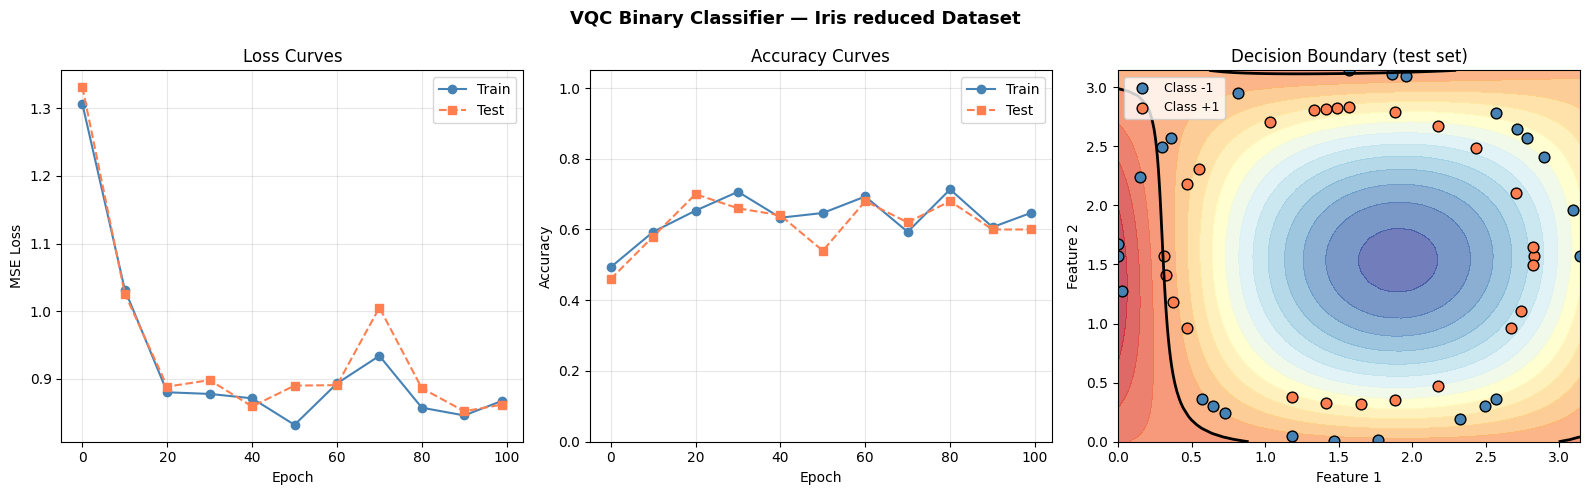

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(log_epochs, train_losses, 'o-', label='Train', color='steelblue')
axes[0].plot(log_epochs, test_losses,  's--', label='Test',  color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(log_epochs, train_accs, 'o-', label='Train', color='steelblue')
axes[1].plot(log_epochs, test_accs,  's--', label='Test',  color='coral')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(0, np.pi, 45), np.linspace(0, np.pi, 45))
grid_pts = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([float(classifier_circuit(params_cls, pt)) for pt in grid_pts]).reshape(xx.shape)

axes[2].contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.7)
axes[2].contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
axes[2].scatter(X_test[y_test==-1, 0], X_test[y_test==-1, 1], c='steelblue', edgecolors='k', s=60, label='Class -1')
axes[2].scatter(X_test[y_test==1,  0], X_test[y_test==1,  1], c='coral',     edgecolors='k', s=60, label='Class +1')
axes[2].set_xlabel('Feature 1'); axes[2].set_ylabel('Feature 2')
axes[2].set_title('Decision Boundary (test set)'); axes[2].legend(fontsize=9)

plt.suptitle('VQC Binary Classifier — Iris reduced Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vqc_classifier_results.png', dpi=120, bbox_inches='tight')
plt.show()


#### Does the VQC overfit? How do you know?
It might be overfitting since we got 100% accuracy in training set but a lower accuracy on test set.


# Problem 4

#### Compute the full kernel matrix K for the Iris binary task

Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2
[[1.     0.6633 0.6796 0.995  0.9226 0.995  0.995  0.74   0.7155 0.6395]
 [0.6633 1.     0.995  0.6796 0.6796 0.6395 0.723  0.99   0.9876 0.3527]
 [0.6796 0.995  1.     0.6878 0.6633 0.6633 0.74   0.995  0.9975 0.3176]
 [0.995  0.6796 0.6878 1.     0.9558 0.9802 0.99   0.7486 0.7197 0.6981]
 [0.9226 0.6796 0.6633 0.9558 1.     0.8813 0.9178 0.723  0.6823 0.8462]
 [0.995  0.6395 0.6633 0.9802 0.8813 1.     0.99   0.723  0.7029 0.5784]
 [0.995  0.723  0.74   0.99   0.9178 0.99   1.     0.7964 0.7743 0.6087]
 [0.74   0.99   0.995  0.7486 0.723  0.723  0.7964 1.     0.9975 0.3711]
 [0.7155 0.9876 0.9975 0.7197 0.6823 0.7029 0.7743 0.9975 1.     0.325 ]
 [0.6395 0.3527 0.3176 0.6981 0.8462 0.5784 0.6087 0.3711 0.325  1.    ]]

Symmetric: True
Diagonal = 1 (self-similarity): True
SI es psd :)


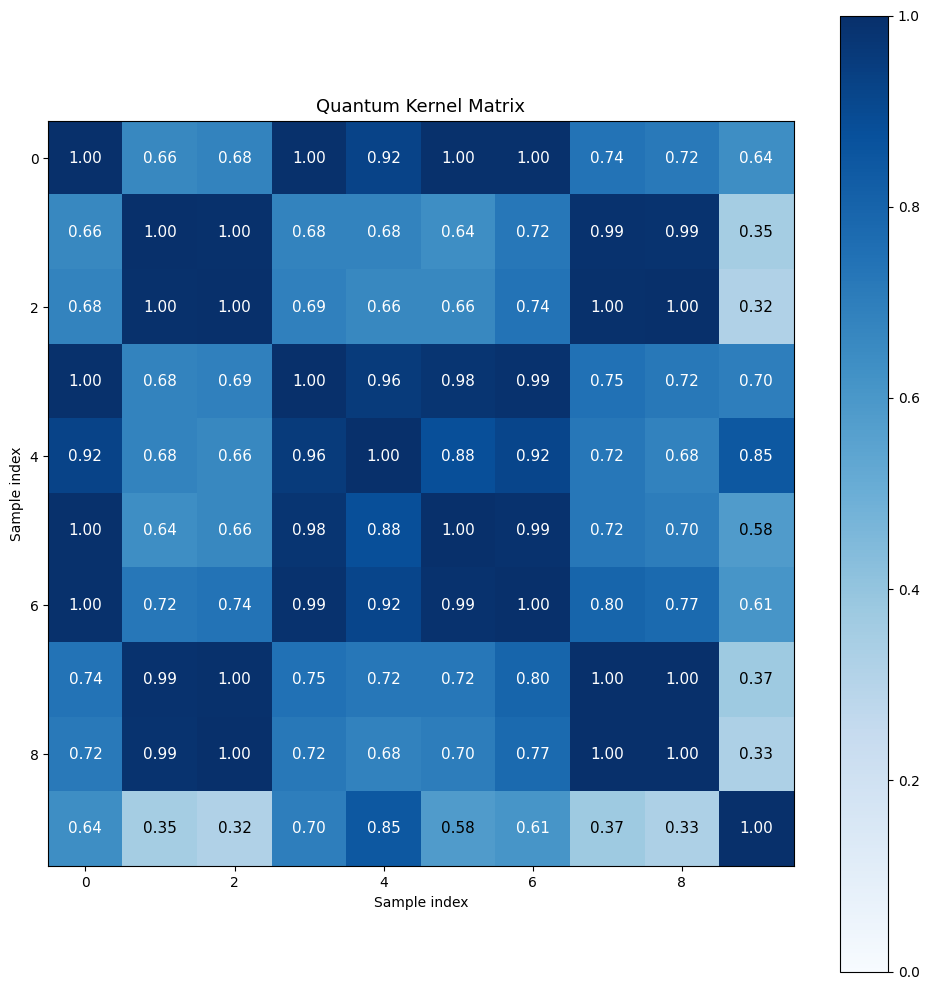

In [114]:
low=0
high=np.pi

rng = np.random.default_rng(seed=42)
rng.shuffle(X_raw)
n_points=10
points=X_raw[:n_points]
# points=X_raw

dev_k_ex = qml.device('default.qubit', wires=2)

@qml.qnode(dev_k_ex)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(2), rotation='Y')
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(2), rotation='Y')
    return qml.probs(wires=range(2))

def quantum_kernel(x1, x2):
    return float(kernel_circuit(x1, x2)[0])  # P(|00>) = |<phi(x1)|phi(x2)>|^2

n = len(points)
K = np.array([[quantum_kernel(points[i], points[j]) for j in range(n)] for i in range(n)])


print('Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2')
print(np.round(K, 4))
print(f'\nSymmetric: {np.allclose(K, K.T)}')
print(f'Diagonal = 1 (self-similarity): {np.allclose(np.diag(K), 1.0)}')

def is_psd(A, tol=1e-8):
    # 1. Check for symmetry
    if not np.allclose(A, A.T, atol=tol):
        return False
    
    # 2. Get eigenvalues for symmetric matrix
    vals = np.linalg.eigvalsh(A)
    
    # 3. Check if all are non-negative within tolerance
    return np.all(vals > -tol)

if(is_psd(K)):
    print("SI es psd :)")
else:
    print("no es :(")


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(K, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_title('Quantum Kernel Matrix', fontsize=13)
ax.set_xlabel('Sample index'); ax.set_ylabel('Sample index')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{K[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if K[i,j] > 0.6 else 'black')
plt.tight_layout()
#plt.savefig('quantum_kernel_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


